# Caregiver Survey — Simplified Response Review

Two studies, same survey, 1,956 responses.

| Study | Description | Responses |
|-------|------------|----------:|
| Study 1 | **Verified caregivers** (known real) | 177 |
| Study 2 | **Online sign-ups** (need screening) | 1,779 |

This notebook walks through **five questions**:

1. What are the 14 screening rules and how do they score?
2. What do real versus flagged responses actually look like?
3. How do the scores distribute, and what does each rule catch?
4. What happens at different refusal thresholds?
5. What goes into the final spreadsheet?

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# Load data (uses cached copy if one was pulled today)
views = ba.build_notebook_views(output_dir, cache_dir)
report_records = views["report_records"]
screen_inputs = ba.build_screen_inputs(output_dir, cache_dir)
source_table = ba.refresh_redcap_cache(project_dir, cache_dir)
audit_table = ba.check_redcap_audit_access(project_dir)

print(f"Responses loaded: {len(screen_inputs):,}")
print(screen_inputs["Group"].value_counts().to_string())

Responses loaded: 1,956
Group
Online sign-ups           1779
Caregivers we verified     177


### Data sources

Both studies are pulled from the REDCap survey system. A saved copy from today is reused after its checksum is verified.

In [2]:
display(source_table)

,Study,Project number,What was pulled,Rows,Where it came from,Saved as
0,Study 1 - verified caregiver sample,4797,"Every answer, including survey timing fields",177,Pulled live today,4797_record_2026-09-11.parquet
1,Study 1 - verified caregiver sample,4797,Field list and branching rules,324,Pulled live today,4797_metadata_2026-09-11.parquet
2,Study 1 - verified caregiver sample,4797,Section list,5,Pulled live today,4797_instrument_2026-09-11.parquet
3,Study 2 - online recruitment sample,4581,"Every answer, including survey timing fields",1779,Pulled live today,4581_record_2026-09-11.parquet
4,Study 2 - online recruitment sample,4581,Field list and branching rules,315,Pulled live today,4581_metadata_2026-09-11.parquet
5,Study 2 - online recruitment sample,4581,Section list,5,Pulled live today,4581_instrument_2026-09-11.parquet


---
# 1. The 14 Screening Rules

Every response is checked against **14 rules**: 9 original (R1–R9) and 5 added after the review meeting (E1–E5).

Each rule is either **Serious** (5 pts) or **Mild** (1 pt).

$$
\text{Risk Score} = (\text{Serious rules violated} \times 5) + (\text{Mild rules violated} \times 1)
$$

In [3]:
# Build the risk table (scores every response against all 14 rules)
risk_table = ba.build_risk_table(output_dir, cache_dir, project_dir)
triaged = ba.build_review_triage(risk_table)

# Rule reference card: code, meaning, severity, points, and fire rate
display(ba.build_rule_key_table(triaged))

,Code,What it means,Where in the survey,Mild or serious,Points on the 1 and 5 scale,Points on the 1 and 2 scale,Added after the meeting,Verified caregivers it fired on,Online sign-ups it fired on
0,R1,Whole survey finished faster than any verified caregiver,Whole survey timing,Serious,5,2,No,0 of 177,"283 of 1,779"
1,R2,Thoughts and feelings section faster than any verified caregiver,Thoughts and feelings timing,Serious,5,2,No,0 of 177,"447 of 1,779"
2,R3,One of the four sections finished below its own speed line,Section timing,Mild,1,1,No,7 of 177,"839 of 1,779"
3,R4,The same answer repeated down a rating block,Rating blocks,Mild,1,1,No,12 of 177,"577 of 1,779"
4,R5,Answer sheet identical to another response,Whole questionnaire,Serious,5,2,No,0 of 177,"0 of 1,779"
5,R6,Arrived within a minute of two or more other sign-ups,Arrival time,Mild,1,1,No,6 of 177,"1,676 of 1,779"
6,R7,Written comment nearly identical to another response,Open text,Mild,1,1,No,0 of 177,"17 of 1,779"
7,R8,Family answers contradict each other,Family Information,Serious,5,2,No,0 of 177,"44 of 1,779"
8,R9,Age and location cannot both be true,Demographics,Serious,5,2,No,2 of 177,"0 of 1,779"
9,E1,Whole survey time sits inside the uncertainty band,Whole survey timing,Mild,1,1,Yes,3 of 177,"104 of 1,779"


### Threshold verification

Every timing threshold was set from the **131 verified caregivers** who finished all four sections. The table below recomputes each threshold from the raw data and confirms it matches the report.

In [4]:
threshold_check = ba.build_threshold_check_table(output_dir, cache_dir)
display(threshold_check)
print(
    f"Recomputed from the {threshold_check.attrs['verified_n']} verified caregivers "
    f"who finished all four sections."
)

,What we check,How the line is worked out,Line used in the report (minutes),Line recomputed here (minutes),Do they match
0,Whole survey too fast,smallest whole-survey time,11.570,11.570,Yes
1,Attitudes section too fast,smallest attitudes time,7.850,7.850,Yes
2,Family Information section rushed,1st percentile of verified times,0.786,0.786,Yes
3,Values section rushed,1st percentile of verified times,0.680,0.680,Yes
4,Attitudes section rushed,1st percentile of verified times,8.568,8.568,Yes
5,Demographics section rushed,1st percentile of verified times,1.100,1.100,Yes


Recomputed from the 131 verified caregivers who finished all four sections.


---
# 2. Real Response Comparisons

Charts are easy to argue with. Two real responses side by side are not.

- **Verified caregiver**: the one closest to the median on survey time.
- **Online sign-up**: the clearest case of each pattern.

### 2.1 Repeated-answer check (R4)

,Question in this block,Online sign-up 296 answered,Verified caregiver 114 answered
0,Angry,2,1
1,Comfortable,2,5
2,Disgusted,2,1
3,How sure the test would need to be,2,1
4,Happy,2,4
5,Odds a younger sibling is also autistic,2,5
6,Sad,2,1
7,Scared,2,1
8,Surprised,2,3
9,When you would want the test done,2,5


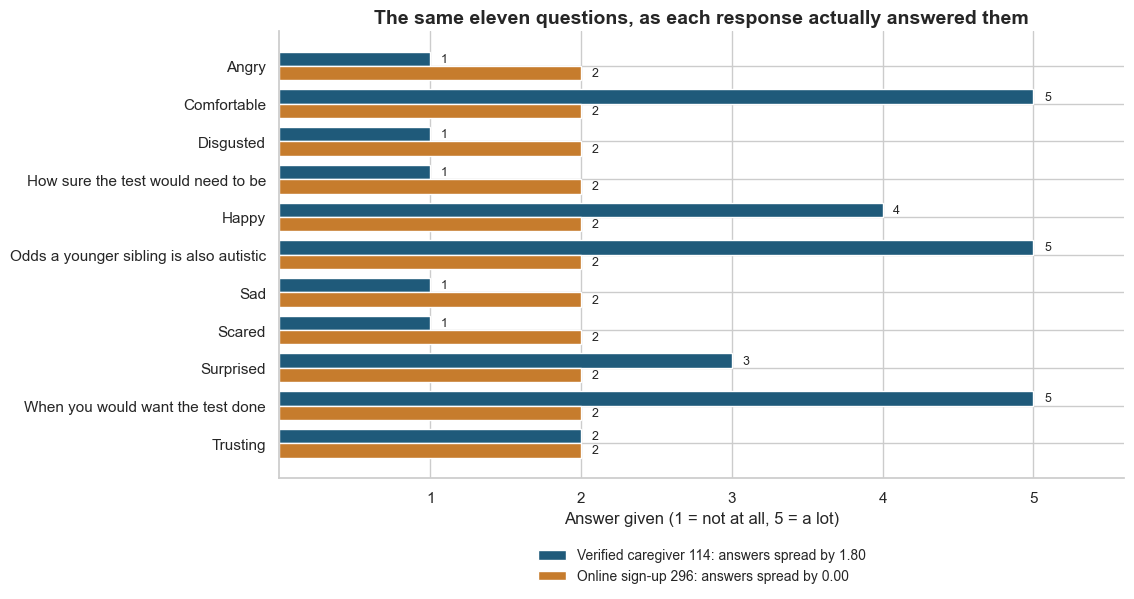

In [5]:
# Side-by-side answers: a flagged response vs. a real caregiver
answer_comparison = ba.build_answer_comparison(screen_inputs, cache_dir)
display(answer_comparison)
ba.plot_answer_comparison(answer_comparison);

#### How the math works

The check measures the *spread* (standard deviation) of answers within a rating block. If every answer is the same number, the spread is 0. Real caregivers vary their answers, so their spread is higher.

In [6]:
# Walk through the arithmetic for both responses
flagged_id = answer_comparison.attrs["flagged_id"]
verified_id = answer_comparison.attrs["verified_id"]
limit = answer_comparison.attrs["limit"]

for who, column in [
    (f"Online sign-up {flagged_id}", f"Online sign-up {flagged_id} answered"),
    (f"Verified caregiver {verified_id}", f"Verified caregiver {verified_id} answered"),
]:
    answers = answer_comparison[column].astype(float)
    n = len(answers)
    average = answers.mean()
    squared_gaps = ((answers - average) ** 2).sum()
    spread = (squared_gaps / (n - 1)) ** 0.5
    verdict = (
        "at or below the line → counts as repeated answers"
        if spread <= limit
        else "above the line → does not count"
    )
    print(who)
    print(f"  {n} answers         : {[int(v) for v in answers]}")
    print(f"  Average            : {average:.4f}")
    print(f"  Sum of squared gaps: {squared_gaps:.4f}")
    print(f"  Spread             : sqrt({squared_gaps:.4f} / {n - 1}) = {spread:.4f}")
    print(f"  Against the line {limit}: {verdict}")
    print()

Online sign-up 296
  11 answers         : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Average            : 2.0000
  Sum of squared gaps: 0.0000
  Spread             : sqrt(0.0000 / 10) = 0.0000
  Against the line 0.82: at or below the line → counts as repeated answers

Verified caregiver 114
  11 answers         : [1, 5, 1, 1, 4, 5, 1, 1, 3, 5, 2]
  Average            : 2.6364
  Sum of squared gaps: 32.5455
  Spread             : sqrt(32.5455 / 10) = 1.8040
  Against the line 0.82: above the line → does not count



### 2.2 Timing check — section by section

,Survey section,Online sign-up 1026 (minutes),Verified caregiver 114 (minutes),Rushed-section line (minutes),Was this section rushed
0,Family Information minutes,0.85,3.93,0.79,No
1,Values minutes,0.10,2.68,0.68,Yes
2,Thoughts and feelings minutes,2.47,17.72,8.57,Yes
3,Demographics minutes,0.75,2.53,1.10,Yes
4,Whole survey,4.17,26.86,11.57,Yes


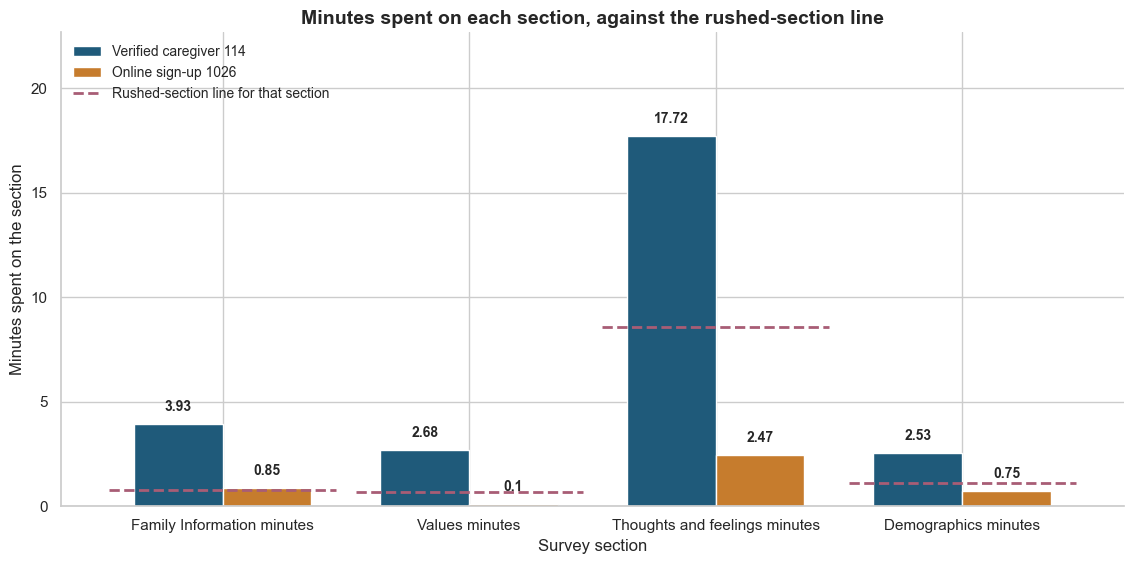

In [7]:
# Section-by-section timing: flagged sign-up vs. real caregiver
section_comparison = ba.build_section_time_comparison(
    screen_inputs, output_dir, cache_dir
)
display(section_comparison)
ba.plot_section_time_comparison(section_comparison);

### 2.3 Family contradiction example (R8)

In [8]:
display(ba.build_family_contradiction_example(output_dir, cache_dir))

,Response,Children reported,Age bands ticked,Which age bands,Why this cannot be true
0,1069,2,3,"3 to 5 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
1,120,2,3,"Under 1 year, 11 to 14 years, 15 to 17 years","3 age bands need at least 3 children, but the response reported 2"
2,167,2,3,"1 to 2 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
3,1774,1,2,"11 to 14 years, 15 to 17 years","2 age bands need at least 2 children, but the response reported 1"


---
# 3. Scoring Results

## 3.1 Rule Scorecard — Grid View

One row per response. Each rule is **Yes** (violated) or **No** (clean). The **Risk Score** sums points using the Mild=1, Serious=5 scale.

This matches the format:

| Record ID | R1 | R2 | … | R9 | Total Rules Violated | Risk Score (Mild=1, Serious=5) |
|-----------|----|----|---|----|--------------------|-------------------------------|

In [9]:
rules_grid = ba.build_rules_grid(triaged)
print(f"Rows: {len(rules_grid):,}   Columns: {rules_grid.shape[1]}")
display(rules_grid.head(10))

Rows: 1,956   Columns: 24


,Study,Record ID,Response key,R1,R2,R3,R4,R5,R6,R7,...,E3,E4,E5,Total Rules Violated,Serious Rules Violated,Mild Rules Violated,"Scoring (Mild = 1, Serious = 5)","Scoring (Mild = 1, Serious = 2)",Recommended action,Final plan
0,Study 1 - verified caregiver sample,101,4797-101,No,No,No,No,No,No,No,...,No,No,Yes,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,No,No,No,No,No,No,No,...,No,No,No,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,No,No,Yes,Yes,No,No,No,...,No,No,No,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,No,No,Yes,No,No,No,No,...,No,No,No,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,No,No,Yes,No,No,No,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,No,No,No,Yes,No,Yes,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
6,Study 1 - verified caregiver sample,40,4797-40,No,No,Yes,No,No,Yes,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
7,Study 1 - verified caregiver sample,92,4797-92,No,No,Yes,No,No,No,No,...,No,No,No,2,0,2,2,2,Check by hand,Read a random sample by hand
8,Study 1 - verified caregiver sample,122,4797-122,No,No,No,No,No,No,No,...,No,No,Yes,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"
9,Study 1 - verified caregiver sample,128,4797-128,No,No,No,Yes,No,No,No,...,No,No,No,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"


## 3.2 Rule Scorecard — List View

Same data, but rules collapsed into one cell (easier to paste into an email).

| Record ID | Rules Violated | Total Rules Violated | Risk Score (Mild=1, Serious=5) |
|-----------|---------------|---------------------|-------------------------------|

In [10]:
rules_list = ba.build_rules_list(triaged)
display(rules_list.head(10))

,Study,Record ID,Response key,Rules violated,"Rules violated, in plain words",Total Number of Rules,Serious Rules Violated,Mild Rules Violated,"Scoring (Mild = 1, Serious = 5)","Scoring (Mild = 1, Serious = 2)",Recommended action,Final plan
0,Study 1 - verified caregiver sample,101,4797-101,"R9, E5",Age and location cannot both be true; Started between midnight and five in the morning,2,1,1,6,3,Do not pay,Do not pay
1,Study 1 - verified caregiver sample,89,4797-89,R9,Age and location cannot both be true,1,1,0,5,2,Check by hand,Read every one by hand
2,Study 1 - verified caregiver sample,143,4797-143,"R3, R4, E1, E2",One of the four sections finished below its own speed line; The same answer repeated d...,4,0,4,4,4,Do not pay,Do not pay
3,Study 1 - verified caregiver sample,168,4797-168,"R3, E1, E2",One of the four sections finished below its own speed line; Whole survey time sits ins...,3,0,3,3,3,Do not pay,Do not pay
4,Study 1 - verified caregiver sample,157,4797-157,"R3, E2",One of the four sections finished below its own speed line; Thoughts and feelings time...,2,0,2,2,2,Check by hand,Read a random sample by hand
5,Study 1 - verified caregiver sample,18,4797-18,"R4, R6",The same answer repeated down a rating block; Arrived within a minute of two or more o...,2,0,2,2,2,Check by hand,Read a random sample by hand
6,Study 1 - verified caregiver sample,40,4797-40,"R3, R6",One of the four sections finished below its own speed line; Arrived within a minute of...,2,0,2,2,2,Check by hand,Read a random sample by hand
7,Study 1 - verified caregiver sample,92,4797-92,"R3, E1",One of the four sections finished below its own speed line; Whole survey time sits ins...,2,0,2,2,2,Check by hand,Read a random sample by hand
8,Study 1 - verified caregiver sample,122,4797-122,E5,Started between midnight and five in the morning,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"
9,Study 1 - verified caregiver sample,128,4797-128,R4,The same answer repeated down a rating block,1,0,1,1,1,Check by hand,"Release, slower than a typical verified caregiver"


## 3.3 Summary — Actions by Group

How many responses fall into each action (Pay / Check by hand / Do not pay), split by study.

In [11]:
display(ba.build_action_summary_table(risk_table))

,Recommended action,Verified caregivers,Online sign-ups,All responses,Share of all responses,What this means
0,Pay now,152,68,220,11.2%,No points. Send the gift card.
1,Check by hand,22,1032,1054,53.9%,One or two points. A person should look before paying.
2,Do not pay,3,679,682,34.9%,3 points or more. Refuse payment.


## 3.4 Score Distribution

In [12]:
display(ba.build_score_distribution_table(risk_table))

,Risk score,Verified caregivers,Online sign-ups,All responses,Recommended action
0,0,151,66,217,Pay now
1,1,18,658,676,Check by hand
2,2,5,375,380,Check by hand
3,3,2,149,151,Do not pay
4,4,1,107,108,Do not pay
5,5,0,114,114,Do not pay
6,6,0,187,187,Do not pay
7,7,0,115,115,Do not pay
8,8,0,5,5,Do not pay
9,9,0,3,3,Do not pay


## 3.5 How Often Each Rule Fires

In [13]:
display(ba.build_check_frequency_table(risk_table))

,Check,How seriously we treat it,Points it adds,Verified caregivers,Online sign-ups,Share of verified caregivers,Share of online sign-ups
0,Whole survey finished faster than any verified caregiver,Serious,2,0 of 177,"283 of 1,779",0.0%,15.9%
1,Whole survey time sits inside the uncertainty band,Mild,1,3 of 177,"104 of 1,779",1.7%,5.8%
2,Thoughts and feelings section faster than any verified caregiver,Serious,2,0 of 177,"447 of 1,779",0.0%,25.1%
3,Thoughts and feelings time sits inside the uncertainty band,Mild,1,3 of 177,"78 of 1,779",1.7%,4.4%
4,One of the four sections finished below its own speed line,Mild,1,7 of 177,"839 of 1,779",4.0%,47.2%
5,The same answer repeated down a rating block,Mild,1,12 of 177,"577 of 1,779",6.8%,32.4%
6,Answer sheet identical to another response,Serious,2,0 of 177,"0 of 1,779",0.0%,0.0%
7,Arrived within a minute of two or more other sign-ups,Mild,1,6 of 177,"1,676 of 1,779",3.4%,94.2%
8,Written comment nearly identical to another response,Mild,1,0 of 177,"17 of 1,779",0.0%,1.0%
9,Family answers contradict each other,Serious,2,0 of 177,"44 of 1,779",0.0%,2.5%


## 3.6 False Alarm Rate on Verified Caregivers

Any verified caregiver refused by the scoring is a mistake we know about. This table shows who was wrongly refused and why.

In [14]:
display(ba.build_false_alarm_summary(risk_table))
display(ba.build_wrongly_refused_detail(risk_table))

,Recommended action,Verified caregivers,Share of the 177 verified caregivers
0,Pay now,152,85.9%
1,Check by hand,22,12.4%
2,Do not pay,3,1.7%


,Record ID,Whole survey minutes,Thoughts and feelings minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Risk score,Recommended action
0,143,12.05,7.85,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,4,Do not pay
1,101,23.67,17.90,Normal,Normal,Age and location cannot both be true; Started between midnight and five in the morning,3,Do not pay
2,168,12.19,8.52,Possibly rushed,Possibly rushed,Whole survey time sits inside the uncertainty band; Thoughts and feelings time sits in...,3,Do not pay


## 3.7 What Happens If the Refusal Line Moves

Each row is a different threshold. The last two columns show the cost in verified caregivers wrongly refused.

In [15]:
display(ba.build_heavy_cutoff_table(triaged))

,Refuse payment at this many points or more,Online sign-ups refused,Verified caregivers refused by mistake,Share of verified caregivers refused by mistake,What this line does,Note
0,3,682,4,2.3%,"Refuses any three mild rules, and any single serious rule","Same number as the line in use, but a much harsher line on this scale"
1,5,497,2,1.1%,Refuses any single serious rule on its own,
2,6,487,1,0.6%,Refuses a serious rule once anything else joins it,
3,7,480,0,0.0%,"Refuses a serious rule with two mild ones, or two serious rules",The lowest line here that refuses no verified caregiver
4,8,416,0,0.0%,"Refuses a serious rule with three mild ones, or two serious rules",
5,10,283,0,0.0%,Refuses two serious rules,
6,12,281,0,0.0%,Refuses two serious rules with two mild ones,


## 3.8 Middle-Pile Triage Summary

The scores leave **~1,000 responses on 1–2 points** — too many to read individually. The triage sorts them into groups and identifies which ones a person actually needs to open.

In [16]:
triage_summary = ba.build_triage_summary(triaged)
display(triage_summary.drop(columns=["Why"]))
print(
    f"Held responses: {triage_summary.attrs['held_total']:,}. "
    f"Responses a person actually opens: {triage_summary.attrs['total_read']}."
)

,Review plan,Online sign-ups,Share of the held pile,Middle survey time (minutes),Responses a person actually reads
0,"Release, arrival timing only",544,52.7%,30.87,0
1,"Release, slower than a typical verified caregiver",145,14.1%,36.85,0
2,Read a random sample by hand,249,24.1%,19.27,59
3,Read every one by hand,2,0.2%,32.34,2
4,Hold until the completion rule is set,92,8.9%,no time recorded,0


Held responses: 1,032. Responses a person actually opens: 61.


---
# 4. Final Spreadsheet

Two files come out of this notebook:

- **Master file**: all 1,956 responses with every check, scores, and actions.
- **Summary file**: the shorter overview without email addresses.

## 4.1 Preview

In [17]:
master_export = ba.build_master_export(risk_table)
print(f"Rows: {len(master_export):,}   Columns: {master_export.shape[1]}")
display(ba.build_master_preview(master_export, rows=8))

Rows: 1,956   Columns: 46


,Study,Record ID,Whole survey minutes,Whole survey speed,Thoughts and feelings speed,Which checks were broken,Checks broken,Risk score,Recommended action
0,Study 2 - online recruitment sample,1026,4.17,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
1,Study 2 - online recruitment sample,120,9.86,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
2,Study 2 - online recruitment sample,571,9.41,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,9,Do not pay
3,Study 2 - online recruitment sample,1119,11.36,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
4,Study 2 - online recruitment sample,1120,11.56,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
5,Study 2 - online recruitment sample,1330,10.06,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
6,Study 2 - online recruitment sample,1332,10.05,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay
7,Study 2 - online recruitment sample,945,10.39,Definitely rushed,Definitely rushed,Whole survey finished faster than any verified caregiver; Thoughts and feelings sectio...,6,8,Do not pay


## 4.2 Column Guide

In [18]:
display(ba.build_master_column_guide(master_export))

,Column,What it holds
0,Study,Which of the two studies the response came from
1,Record ID,The response number in the survey system
2,Email address,"The address given on the demographics page, for spot checking"
3,University email address,Yes when the address ends in .edu
4,Started,When the sign-up screen was submitted
5,Last section handed in,When the last of the four sections was submitted
6,Started overnight,Yes when the sign-up landed between midnight and five in the morning
7,Family Information minutes,Minutes spent on the Family Information section
8,Values minutes,Minutes spent on the Values section
9,Thoughts and feelings minutes,"Minutes spent on the Thoughts, Feelings, and Attitudes section"


## 4.3 Export

In [19]:
master_workbook = ba.export_master_workbook(
    output_dir=output_dir,
    cache_dir=cache_dir,
    project_dir=project_dir,
    source_table=source_table,
    audit_table=audit_table,
)
print(f"Master file: {master_workbook.relative_to(project_dir)}")
print(pd.ExcelFile(master_workbook).sheet_names)

report_workbook = ba.export_simple_excel(
    output_dir=output_dir,
    cache_dir=cache_dir,
    excel_filename="ESD_Bot_Analysis_Simple_Summary.xlsx",
)
print(f"\nSummary file: {report_workbook.relative_to(project_dir)}")
print(pd.ExcelFile(report_workbook).sheet_names)

Master file: Caregiver Outputs/restricted/ESD_Response_Review_Master.xlsx
['Read me first', 'Summary', 'All responses', 'Pay now', 'Check by hand', 'Do not pay', 'Checks and points', 'Time limits', 'If the line moves', 'Spot checks', 'Handling the held pile', 'Rule key', 'Rules grid', 'Rules list', 'Read by hand', 'Where the data came from']



Summary file: Caregiver Outputs/ESD_Bot_Analysis_Simple_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


---
# 5. Key Takeaways

| Finding | Detail |
|---------|--------|
| **Time limits are defensible** | Every limit was recomputed from raw data and matched. |
| **Points separate the two studies cleanly** | 151 of 177 verified caregivers score zero. |
| **The refusal line is a choice** | Moving from 3 pts to 5 pts removes every wrongly-refused caregiver and still refuses 424 online sign-ups. |
| **The middle pile is manageable** | 1,032 held responses → 61 that someone actually reads. |
| **Arrival timing is the strongest study-level signal** | 94.2% of online sign-ups arrived within a minute of another. |
| **Email checks cost nothing** | No response used a throwaway service; 7 carry a university address. |
| **Counting Serious=5 is a real option** | At a line of 7, refuses 480 online sign-ups and zero verified caregivers. |

### Three decisions needed before payment:

1. Does an unfinished survey earn a gift card?
2. Which scoring scale: Serious=2 or Serious=5?
3. Where does the refusal line sit on that scale?